# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inception Network

In this notebook we build a model of the Inception network and apply it to the configuration matrix of CICY 4-folds.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import time
import json
import joblib
from nn_tools.utils.plotutils import *
from nn_tools.utils.datacreate import *
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *
from IPython.display import Image

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
sns.set()
ratio   = lambda x, y: (6 * y, 5 * x)

os.makedirs('./img', exist_ok=True)
os.makedirs('./models', exist_ok=True)

In [4]:
random_state = 123
np.random.seed(random_state)
tf.random.set_seed(random_state)

## Create a Saving Directory

Each model will be assigned to a different directory based on the time of running.

In [5]:
prefix  = 'inception'
name    = time.strftime('%Y%m%d_%H%M%S', time.localtime())
now_dir = os.path.join('./models', prefix + '_' + name)

os.makedirs(now_dir)

In [6]:
print(f'Current working directory: {now_dir}')

Current working directory: ./models/inception_20201127_202619


## Load the Dataset

We then download the JSON file containing the configuration matrix and the Hodge numbers of the CICY.

In [7]:
df     = pd.read_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz', orient='index')
n_rows, n_cols = df.shape

We then split it into train, validation and test sets:

In [8]:
df_splits = {'train': 0.98, 'val_test': 0.5}

# training set
df_train = df.sample(frac=df_splits['train'], random_state=random_state)
df_oos   = df.loc[~df.index.isin(df_train.index)]

n_train = df_train.shape[0]

# validation/test
df_val   = df_oos.sample(frac=df_splits['val_test'], random_state=random_state)
df_test  = df_oos.loc[~df_oos.index.isin(df_val.index)]

n_val  = df_val.shape[0]
n_test = df_test.shape[0]

assert n_train + n_val + n_test == n_rows

In [9]:
del df, df_oos

## Outliers in the Training Set

We then study the outliers in the training set:

In [10]:
low, high = 0.025, 0.975
quantile = df_train.quantile([low, high])

# remove outliers
df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low]) & (df_train['h11'] <= quantile['h11'].loc[high])
                        &
                        (df_train['h21'] >= quantile['h21'].loc[low]) & (df_train['h21'] <= quantile['h21'].loc[high])
                        &
                        (df_train['h31'] >= quantile['h31'].loc[low]) & (df_train['h31'] <= quantile['h31'].loc[high])
                        &
                        (df_train['h22'] >= quantile['h22'].loc[low]) & (df_train['h22'] <= quantile['h22'].loc[high])
                       ]
n_train_pruned = df_train.shape[0]

In [11]:
print(f'Samples removed: {n_train - n_train_pruned:d} ({(n_train - n_train_pruned) / n_train:.2f}% of the training set, {(n_train - n_train_pruned) / n_rows:.2f}% of the total set)')

Samples removed: 76528 (0.09% of the training set, 0.08% of the total set)


## Rescale the Matrices

We then rescale the matrices in the sets to improve the deep learning results:

In [12]:
rescaling = {'min': df_train['matrix'].apply(lambda x: np.min(x)).min(),
             'max': df_train['matrix'].apply(lambda x: np.max(x)).max()
            }

## Feature and Label Creation

We then create the features and the labels.

In [13]:
reshape = (16, 20, 1)

In [14]:
X_train = create_features(df_train['matrix'], rescaling=rescaling, reshape=reshape)
X_val   = create_features(df_val['matrix'], rescaling=rescaling, reshape=reshape)
X_test  = create_features(df_test['matrix'], rescaling=rescaling, reshape=reshape)

In [15]:
y_train = create_labels(df_train[['h11', 'h21', 'h31', 'h22']])
y_val   = create_labels(df_val[['h11', 'h21', 'h31', 'h22']])
y_test  = create_labels(df_test[['h11', 'h21', 'h31', 'h22']])

In [16]:
del df_train, df_val, df_test

## Inception Model

We then start to build the Inception model to be trained on the configuration matrices.

### Build the Model

In [22]:
model_data = {'input_shape':   reshape,
              'name':          'matrix',
              'learning_rate': 1.0e-3,
              'conv_1b1':      False,
              'conv_layers':   [128, 64, 32],
              'conv_alpha':    0.0,
              'conv_class':    None,
              'conv_single':   False,
              'conv_red':      0,
              'feat_map':      0,
              'recurrent':     False,
              'fc_layers':     [],
              'fc_alpha':      0.0,
              'dropout':       0.25,
              'full_dropout':  0.02,
              'batchnorm':     0.0,
              'last_relu':     True,
              'loss_weights':  [0.15, 0.25, 0.20, 0.40],
              'l1_reg':        1.0e-3,
              'l2_reg':        1.0e-3,
              'output_layers': True,
              'random_state':  random_state
             }

with open(os.path.join(now_dir, 'model_data.json'), 'w') as f:
    json.dump(model_data, f)

In [23]:
inception = nn_inception(**model_data)
inception.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 128)  2176        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 128)  2688        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 128)  0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

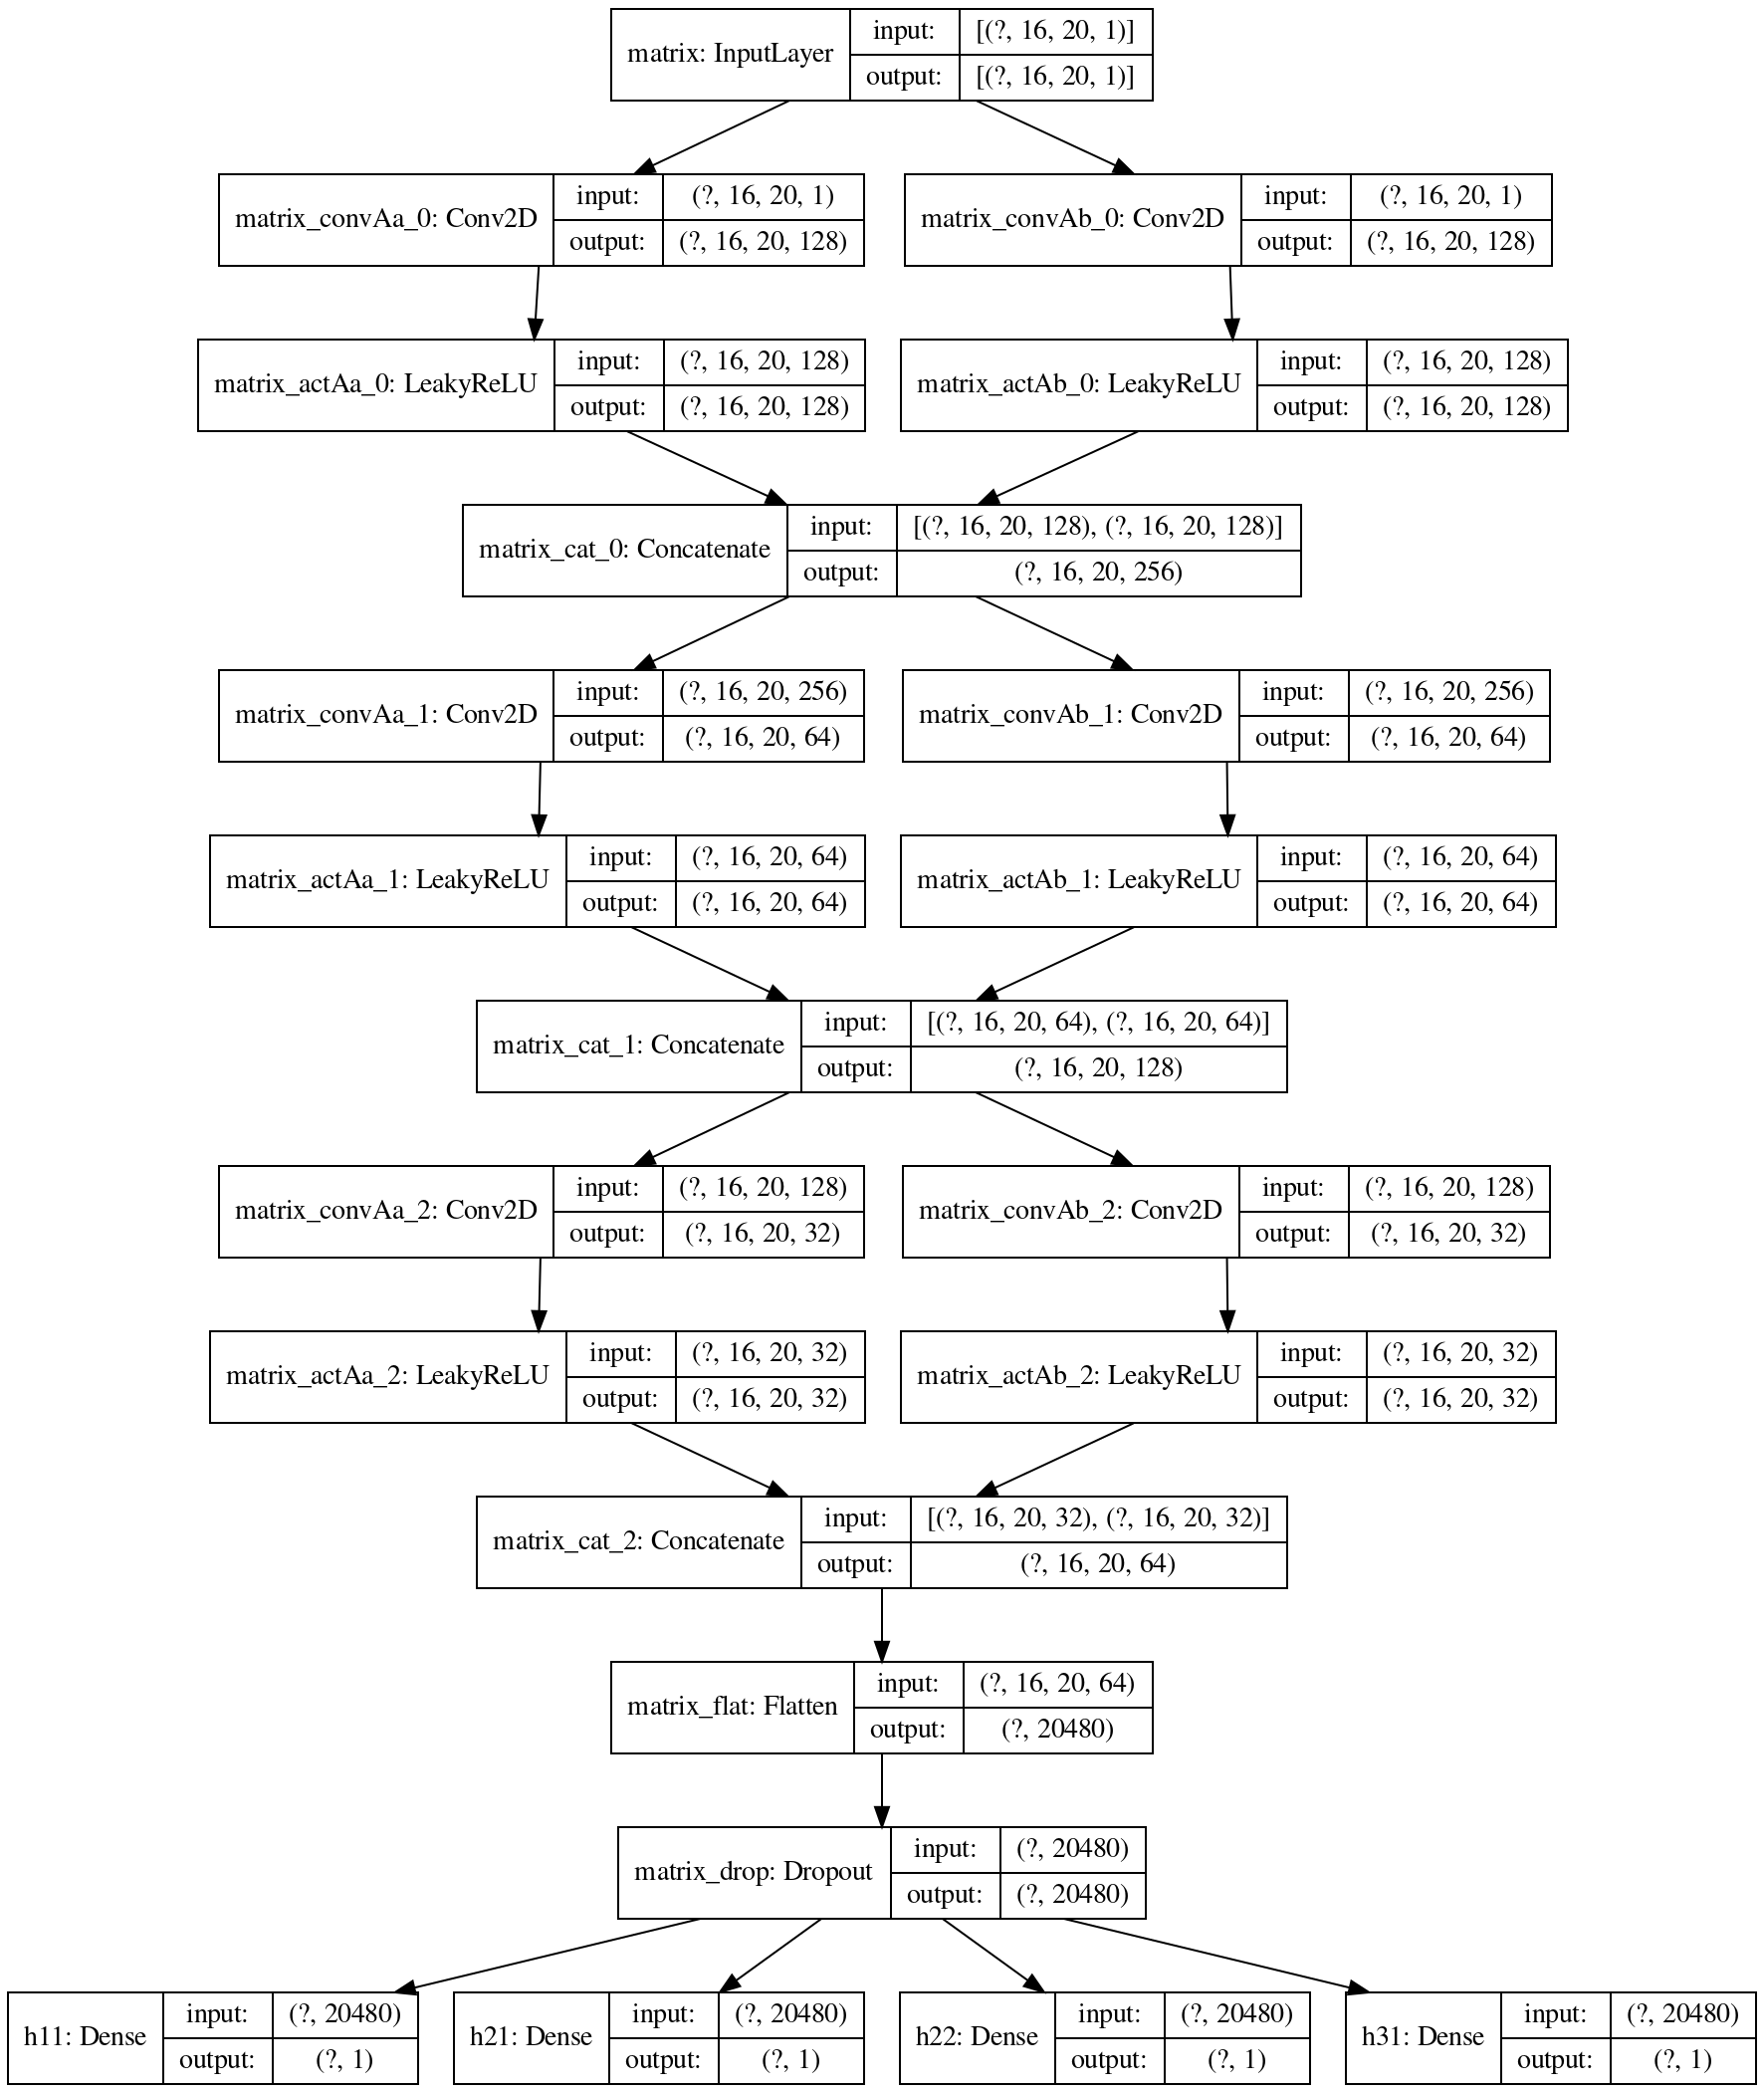

In [24]:
inception_graph = keras.utils.model_to_dot(inception, show_shapes=True, dpi=144)
inception_graph.write_pdf('./img/inception.pdf')
Image(inception_graph.create_png(), width=480)

### Train the Model

In [20]:
fit_data = {'epochs':        10,
            'batch_size':    32,
            'reduce_lr':     10,
            'stat_interval': 2
           }

with open(os.path.join(now_dir, 'fit_data.json'), 'w') as f:
    json.dump(fit_data, f)

In [21]:
callbacks = [keras.callbacks.ModelCheckpoint(os.path.join(now_dir, 'inception_val_loss.h5'), monitor='val_loss', save_best_only=True),
             keras.callbacks.ModelCheckpoint(os.path.join(now_dir, 'inception_val_h11_loss.h5'), monitor='val_h11_loss', save_best_only=True),
             keras.callbacks.ModelCheckpoint(os.path.join(now_dir, 'inception_val_h21_loss.h5'), monitor='val_h21_loss', save_best_only=True),
             keras.callbacks.ModelCheckpoint(os.path.join(now_dir, 'inception_val_h31_loss.h5'), monitor='val_h31_loss', save_best_only=True),
             keras.callbacks.ModelCheckpoint(os.path.join(now_dir, 'inception_val_h22_loss.h5'), monitor='val_h22_loss', save_best_only=True),
             keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=fit_data['reduce_lr'], min_lr=1.0e-6),
             PrintCheckpoint(fit_data['stat_interval'])
            ]

inception_hst = inception.fit(x=X_train,
                              y=y_train,
                              batch_size=fit_data['batch_size'],
                              epochs=fit_data['epochs'],
                              verbose=0,
                              callbacks=callbacks,
                              validation_data=(X_val, y_val)
                             )

Training has started. Callouts will be printed every 2 epochs.

Training epoch 1. Started on 27/11/2020 at 20:28:12.

    Average epoch training time: 00 hours, 14 minutes, 01 seconds

    loss = 674.444
    h11_loss = 105.403
    h21_loss = 1.820
    h22_loss = 171.011
    h31_loss = 1543.370
    h11_mean_squared_error = 105.403
    h11_mean_absolute_error = 10.055
    h21_mean_squared_error = 1.820
    h21_mean_absolute_error = 0.600
    h22_mean_squared_error = 171.011
    h22_mean_absolute_error = 8.257
    h31_mean_squared_error = 1543.370
    h31_mean_absolute_error = 38.141
    val_loss = 757.667
    val_h11_loss = 106.777
    val_h21_loss = 4.296
    val_h22_loss = 196.871
    val_h31_loss = 1743.545
    val_h11_mean_squared_error = 106.777
    val_h11_mean_absolute_error = 10.048
    val_h21_mean_squared_error = 4.296
    val_h21_mean_absolute_error = 0.818
    val_h22_mean_squared_error = 196.871
    val_h22_mean_absolute_error = 7.381
    val_h31_mean_squared_error = 1743.54

KeyboardInterrupt: 

## Visualisation of the Training Data

We plot the metrics and the loss of the training for reference.

In [ ]:
inception_hst = pd.DataFrame(inception_hst.history)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst[['loss', 'val_loss']],
             palette=['tab:blue', 'tab:red'],
             ax=ax
            )
ax.set(title='Loss Function (MSE)',
       xlabel='epochs',
       ylabel='loss',
       yscale='log'
      )
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

savefig('inception_loss', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst['lr'],
             ax=ax
            )
ax.set(title='Learning Rate',
       xlabel='epochs',
       ylabel='learning rate',
       yscale='log'
      )

savefig('inception_lr', fig, show=True)

## Reload Best Weights and Compute the Predictions

We then reload the best weights and compute the predictions of the model in test mode.

In [ ]:
models = {'full_model': keras.models.load_model(os.path.join(now_dir, 'inception_val_loss.h5')),
          'h11_model':  keras.models.load_model(os.path.join(now_dir, 'inception_val_h11_loss.h5')),
          'h21_model':  keras.models.load_model(os.path.join(now_dir, 'inception_val_h21_loss.h5')),
          'h31_model':  keras.models.load_model(os.path.join(now_dir, 'inception_val_h31_loss.h5')),
          'h22_model':  keras.models.load_model(os.path.join(now_dir, 'inception_val_h22_loss.h5'))
         }

In [ ]:
predictions = {'training':   {key: mod.predict(X_train) for key, mod in models.items()},
               'validation': {key: mod.predict(X_val) for key, mod in models.items()},
               'test':       {key: mod.predict(X_test) for key, mod in models.items()},
              }
joblib.dump(predictions, os.path.join(now_dir, 'inception_predictions.joblib.gz'), compress=9)

In [ ]:
true_values = {'training':   dict(y_train),
               'validation': dict(y_val),
               'test':       dict(y_test),
              }
joblib.dump(true_values, os.path.join(now_dir, 'inception_ground_truth.joblib.gz'), compress=9)

In [ ]:
residuals = {fold: {model: \
                    {label: predictions[fold][model][label].reshape(-1,) - true_values[fold][label].reshape(-1,) \
                            for label in predictions[fold][model].keys()
                    } for model in predictions[fold].keys()
                   } for fold in predictions.keys()
            }
joblib.dump(predictions, os.path.join(now_dir, 'inception_residuals.joblib.gz'), compress=9)

## Visualise the Predictions

We can finally visualise the results of the different models.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['full_model']['h11'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['full_model']['h11'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['full_model']['h11'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{1,1}$ (full model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_full_model_h11_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['full_model']['h21'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['full_model']['h21'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['full_model']['h21'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{2,1}$ (full model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_full_model_h21_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['full_model']['h31'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['full_model']['h31'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['full_model']['h31'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{3,1}$ (full model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_full_model_h31_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['full_model']['h22'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['full_model']['h22'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['full_model']['h22'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{2,2}$ (full model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_full_model_h22_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['h11_model']['h11'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['h11_model']['h11'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['h11_model']['h11'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{1,1}$ (optimised model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_h11_model_h11_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['h21_model']['h21'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['h21_model']['h21'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['h21_model']['h21'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{2,1}$ (optimised model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_h21_model_h21_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['h31_model']['h31'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['h31_model']['h31'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['h31_model']['h31'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{3,1}$ (optimised model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_h31_model_h31_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=residuals['training']['h22_model']['h22'],
             color='tab:blue',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['validation']['h22_model']['h22'],
             color='tab:red',
             alpha=0.35,
             stat='count',
             ax=ax
            )
sns.histplot(data=residuals['test']['h22_model']['h22'],
             color='tab:green',
             alpha=0.35,
             stat='count',
             ax=ax
            )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Distribution of the residuals for $h^{2,2}$ (optimised model)',
       xlabel='residuals',
       ylabel='count',
       yscale='log'
      )

savefig('inception_h22_model_h22_residuals', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['full_model']['h11'].reshape(-1,),
                y=residuals['training']['full_model']['h11'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['full_model']['h11'].reshape(-1,),
                y=residuals['validation']['full_model']['h11'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['full_model']['h11'].reshape(-1,),
                y=residuals['test']['full_model']['h11'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{1,1}$ (full model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_full_model_h11_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['full_model']['h21'].reshape(-1,),
                y=residuals['training']['full_model']['h21'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['full_model']['h21'].reshape(-1,),
                y=residuals['validation']['full_model']['h21'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['full_model']['h21'].reshape(-1,),
                y=residuals['test']['full_model']['h21'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{2,1}$ (full model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_full_model_h21_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['full_model']['h31'].reshape(-1,),
                y=residuals['training']['full_model']['h31'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['full_model']['h31'].reshape(-1,),
                y=residuals['validation']['full_model']['h31'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['full_model']['h31'].reshape(-1,),
                y=residuals['test']['full_model']['h31'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{3,1}$ (full model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_full_model_h31_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['full_model']['h22'].reshape(-1,),
                y=residuals['training']['full_model']['h22'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['full_model']['h22'].reshape(-1,),
                y=residuals['validation']['full_model']['h22'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['full_model']['h22'].reshape(-1,),
                y=residuals['test']['full_model']['h22'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{2,2}$ (full model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_full_model_h22_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['h11_model']['h11'].reshape(-1,),
                y=residuals['training']['h11_model']['h11'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['h11_model']['h11'].reshape(-1,),
                y=residuals['validation']['h11_model']['h11'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['h11_model']['h11'].reshape(-1,),
                y=residuals['test']['h11_model']['h11'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{1,1}$ (optimised model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_h11_model_h11_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['h21_model']['h21'].reshape(-1,),
                y=residuals['training']['h21_model']['h21'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['h21_model']['h21'].reshape(-1,),
                y=residuals['validation']['h21_model']['h21'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['h21_model']['h21'].reshape(-1,),
                y=residuals['test']['h21_model']['h21'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{2,1}$ (optimised model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_h21_model_h21_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['h31_model']['h31'].reshape(-1,),
                y=residuals['training']['h31_model']['h31'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['h31_model']['h31'].reshape(-1,),
                y=residuals['validation']['h31_model']['h31'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['h31_model']['h31'].reshape(-1,),
                y=residuals['test']['h31_model']['h31'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{3,1}$ (optimised model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_h31_model_h31_resplot', fig, show=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(x=predictions['training']['h22_model']['h22'].reshape(-1,),
                y=residuals['training']['h22_model']['h22'],
                color='tab:blue',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['validation']['h22_model']['h22'].reshape(-1,),
                y=residuals['validation']['h22_model']['h22'],
                color='tab:red',
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=predictions['test']['h22_model']['h22'].reshape(-1,),
                y=residuals['test']['h22_model']['h22'],
                color='tab:green',
                alpha=0.35,
                ax=ax
               )
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
ax.set(title='Residual plot for $h^{2,2}$ (optimised model)',
       xlabel='predictions',
       ylabel='residuals'
      )

savefig('inception_h22_model_h22_resplot', fig, show=True)

## Compute the Metrics

We finally compute the metrics of the model.

In [ ]:
metrics = {fold: \
           {model: \
            {'mse': {label: np.mean(np.square(residuals[fold][model][label]))
                     for label in predictions[fold][model].keys()
                    },
             'mae': {label: np.mean(np.abs(residuals[fold][model][label]))
                     for label in predictions[fold][model].keys()
                    },
             'acc': {label: np.equal(true_values[fold][label],
                                     np.rint(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                    ).mean()
                     for label in predictions[fold][model].keys()
                    }
            } for model in predictions[fold].keys()
           } for fold in predictions.keys()
          }
joblib.dump(true_values, os.path.join(now_dir, 'inception_metrics.joblib.gz'), compress=9)

In [ ]:
with open(os.path.join(now_dir, 'metrics.txt'), 'w') as out_file:
    for file in [sys.stdout, out_file]:
        for folds, models_dict in metrics.items():
            print('\n=====================', file=file)
            print(f'{folds.upper()}:', file=file)
            print('=====================', file=file)
            for mod, metrics_dict in models_dict.items():
                print(f'\n  {mod}:', file=file)
                print('  ___________________', file=file)
                for met, labels_dict in metrics_dict.items():
                    print(f'\n    > {met.upper()}:', file=file)
                    for lab, met_value in labels_dict.items():
                        print(f'      * {lab.lower()}: {met_value:.3f}', file=file)